# Test `GaussianErfcPlateau` Python bindings

Minimal check for the Aare Minuit2 object API against a SciPy `curve_fit` reference.

Model:

\[
f(x) =
A \exp\left[-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2\right]
+
\frac{S}{2}\left[
1 - \operatorname{erf}\left(
\frac{x-\mu}{\sqrt{2}\sigma}
\right)
\right]
\]

Parameter order:

```text
[A, S, mu, sigma]
```

In [1]:
import time
import numpy as np
np.set_printoptions(suppress=True, precision=6)

import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.optimize import curve_fit
from pprint import pprint

import sys
sys.path.insert(0, "/home/ferjao_k/sw/aare/build")

try:
    from aare import GaussianErfcPlateau
except ImportError:
    import aare
    print("Could not import GaussianErfcPlateau directly.")
    print("Available Gaussian/Erf/Plateau-like names:")
    pprint([name for name in dir(aare)
            if any(token.lower() in name.lower()
                   for token in ("gauss", "erf", "plateau"))])
    raise

In [2]:
def gaussian_erfc_plateau(x, p):
    A, S, mu, sigma = p
    z = (x - mu) / (np.sqrt(2.0) * sigma)
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2) + 0.5 * S * (1.0 - erf(z))

def gaussian_erfc_plateau_curve_fit(x, A, S, mu, sigma):
    return gaussian_erfc_plateau(x, np.array([A, S, mu, sigma], dtype=float))

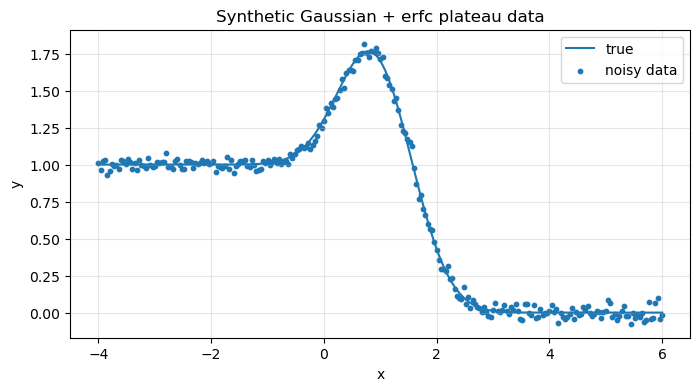

In [3]:
# Synthetic data
rng = np.random.default_rng(42)

x = np.linspace(-4.0, 6.0, 251)

p_true = np.array([
    1.20,  # A: Gaussian amplitude
    1.00,  # S: left plateau height
    1.00,  # mu: shared center / step position
    0.65,  # sigma: shared width
])

noise_sigma = 0.035

y_true = gaussian_erfc_plateau(x, p_true)
y = y_true + rng.normal(0.0, noise_sigma, size=x.shape)
y_err = np.full_like(x, noise_sigma)

plt.figure(figsize=(8, 4))
plt.plot(x, y_true, label="true")
plt.scatter(x, y, s=10, label="noisy data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic Gaussian + erfc plateau data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# SciPy reference fit
p0_ref = np.array([1.0, 0.8, 0.5, 0.8])

bounds_ref = (
    [-np.inf, -np.inf, -np.inf, 1e-12],
    [ np.inf,  np.inf,  np.inf, np.inf],
)

p_scipy, cov_scipy = curve_fit(
    gaussian_erfc_plateau_curve_fit,
    x,
    y,
    p0=p0_ref,
    sigma=y_err,
    absolute_sigma=True,
    bounds=bounds_ref,
    maxfev=20_000,
)

print("True params : ", p_true)
print("SciPy params: ", p_scipy)
print("SciPy abs error:", np.abs(p_scipy - p_true))

True params :  [1.2  1.   1.   0.65]
SciPy params:  [1.19916  1.000479 1.005638 0.64249 ]
SciPy abs error: [0.00084  0.000479 0.005638 0.00751 ]


In [5]:
# Aare / Minuit2 object API fit
model = GaussianErfcPlateau()

print("Parameter list:")
print(model.par_names)
print("n_par:", model.n_par)
print()

# Optional: provide explicit starts close enough to avoid relying only on estimate_par().
model.SetParameter("A", 1.0)
model.SetParameter("S", 0.8)
model.SetParameter("mu", 0.5)
model.SetParameter("sigma", 0.8)

# Optional fit settings
model.compute_errors = True
model.max_calls = 1000
model.tolerance = 0.01

print("== Tuned fit settings ==")
print(f"max_calls      : {model.max_calls}")
print(f"tolerance      : {model.tolerance}")
print(f"compute_errors : {model.compute_errors}")
print()

res_aare = model.fit(x, y, y_err)

print("== Aare / Minuit2 result ==")
pprint(res_aare, sort_dicts=False)

p_aare = np.array(res_aare["par"], dtype=float)

print()
print("True params     : ", p_true)
print("SciPy params    : ", p_scipy)
print("Aare params     : ", p_aare)
print("SciPy abs error : ", np.abs(p_scipy - p_true))
print("Aare abs error  : ", np.abs(p_aare - p_true))

Parameter list:
['A', 'S', 'mu', 'sigma']
n_par: 4

== Tuned fit settings ==
max_calls      : 1000
tolerance      : 0.01
compute_errors : True

== Aare / Minuit2 result ==
{'par': array([1.199158, 1.000478, 1.00564 , 0.642494]),
 'par_err': array([0.008525, 0.003768, 0.005623, 0.005163]),
 'chi2': array([218.22232])}

True params     :  [1.2  1.   1.   0.65]
SciPy params    :  [1.19916  1.000479 1.005638 0.64249 ]
Aare params     :  [1.199158 1.000478 1.00564  0.642494]
SciPy abs error :  [0.00084  0.000479 0.005638 0.00751 ]
Aare abs error  :  [0.000842 0.000478 0.00564  0.007506]


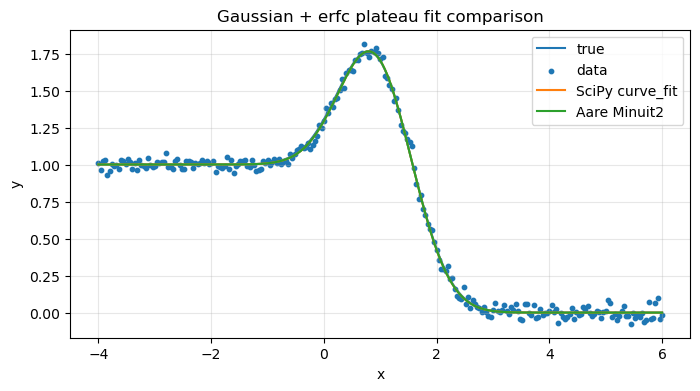

In [6]:
plt.figure(figsize=(8, 4))

plt.plot(x, y_true, label="true")
plt.scatter(x, y, s=10, label="data")
plt.plot(x, gaussian_erfc_plateau(x, p_scipy), linewidth=1.5, label="SciPy curve_fit")
plt.plot(x, model(x, p_aare), linewidth=1.5, label="Aare Minuit2")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Gaussian + erfc plateau fit comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
def bench(fn, n_repeats=200):
    for _ in range(3):
        fn()

    t0 = time.perf_counter()
    for _ in range(n_repeats):
        res = fn()
    t1 = time.perf_counter()

    return res, (t1 - t0) / n_repeats

def fit_scipy_once():
    return curve_fit(
        gaussian_erfc_plateau_curve_fit,
        x,
        y,
        p0=p0_ref,
        sigma=y_err,
        absolute_sigma=True,
        bounds=bounds_ref,
        maxfev=20_000,
    )[0]

def fit_aare_once():
    m = GaussianErfcPlateau()
    m.SetParameter("A", 1.0)
    m.SetParameter("S", 0.8)
    m.SetParameter("mu", 0.5)
    m.SetParameter("sigma", 0.8)
    m.max_calls = 1000
    m.tolerance = 0.01
    return m.fit(x, y, y_err)["par"]

p_scipy_bench, t_scipy = bench(fit_scipy_once, n_repeats=200)
p_aare_bench, t_aare = bench(fit_aare_once, n_repeats=200)

print(f"SciPy curve_fit : {1e3*t_scipy:.3f} ms")
print(f"Aare Minuit2    : {1e3*t_aare:.3f} ms")
print()
print("SciPy bench params:", p_scipy_bench)
print("Aare bench params :", p_aare_bench)

SciPy curve_fit : 3.748 ms
Aare Minuit2    : 0.356 ms

SciPy bench params: [1.19916  1.000479 1.005638 0.64249 ]
Aare bench params : [1.199158 1.000478 1.00564  0.642494]
